#### Imports

In [2]:
from  Rolling_Intrinsic_QH import load_fake_data, run_optimization_quarterhours_repositioning, get_net_trades, load_real_data, get_average_prices
import os
import pandas as pd
from loguru import logger
import sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from matplotlib.patches import Ellipse
import matplotlib.dates as mdates
logger.remove()
df = pd.read_parquet("../../id_prices.parquet")

c:\Users\UnmuBhar\Documents\Intraday Research\POCs\Rolling-Intrinsic-BESS-Intraday-Trading\Code\Rolling Intrinsic
c:\Users\UnmuBhar\Documents\Intraday Research\POCs\Rolling-Intrinsic-BESS-Intraday-Trading\Code\Rolling Intrinsic


# EDA

***

### Look at the price development of one single ID product as you approach the delivery time. 

<Axes: title={'center': 'Price Development of 1 MWh at 2025-02-01 01:00:00'}, xlabel='Time of Executed Trade', ylabel='€/MWh'>

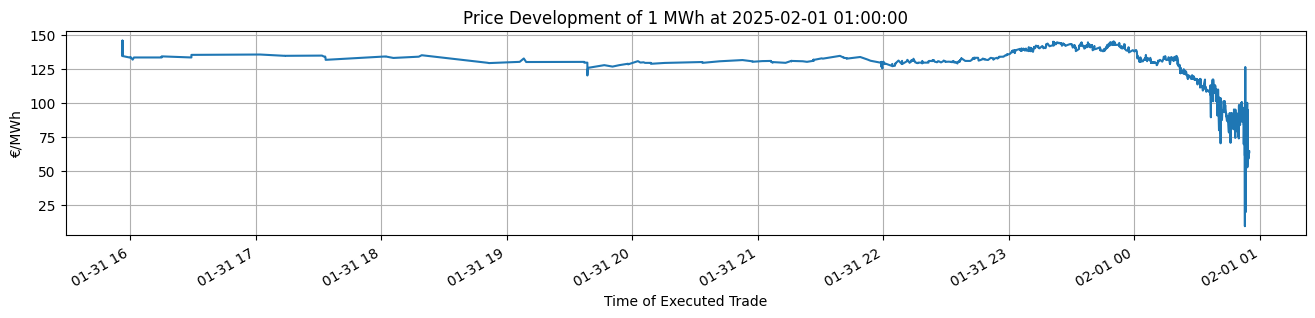

In [3]:
product = "2025-02-01 01:00:00"
df[df.deliverystart==product].loc[:,"price"].plot(title=f"Price Development of 1 MWh at {product}",
                                                                      ylabel="€/MWh",
                                                                      xlabel="Time of Executed Trade",
                                                                      grid=True,
                                                                      figsize=(16,3))

#### The chart below shows trading activity of many different products as they get closer to delivery time for RW 5min and 15min

Text(300, 32, '')

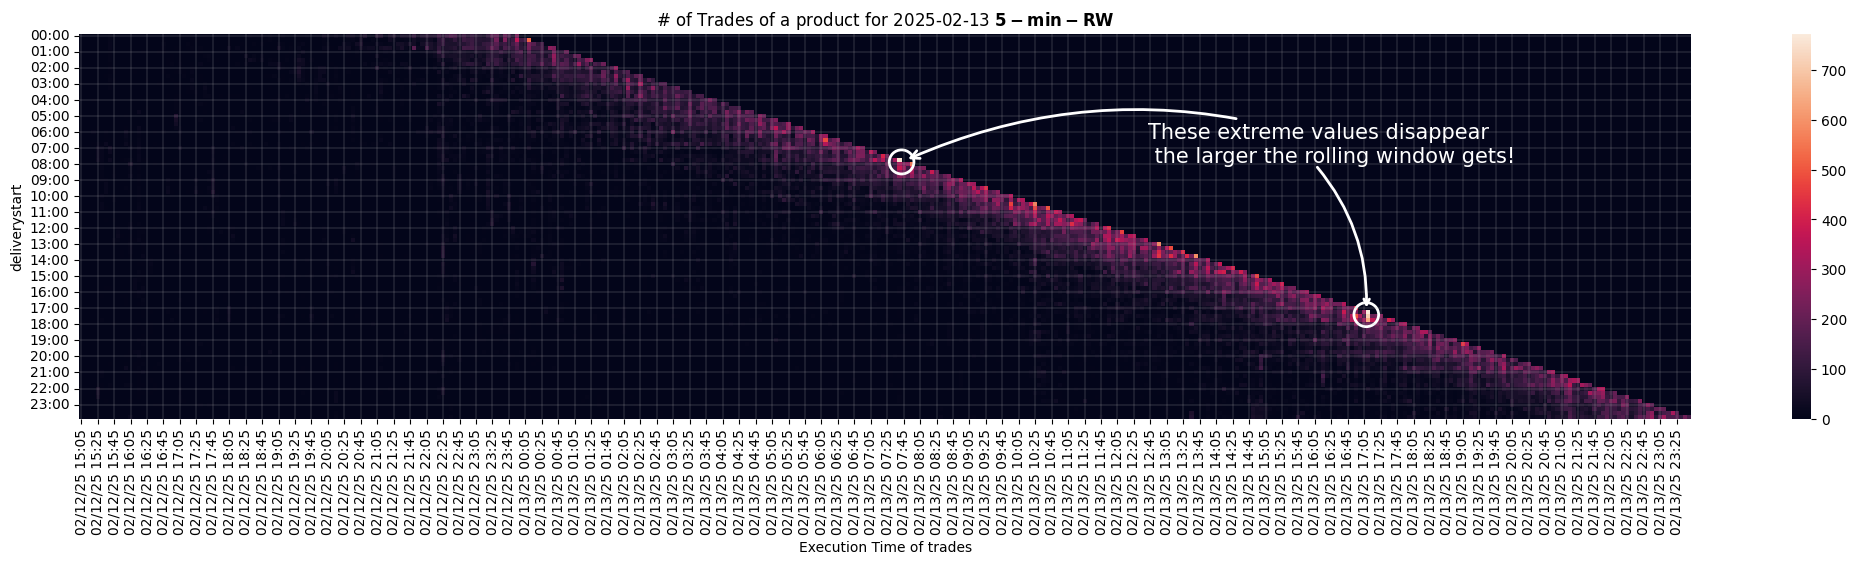

In [4]:
exec_time_range = slice(pd.Timestamp("02.12.2025",tz="Europe/Berlin"),
                        pd.Timestamp("02.14.2025",tz="Europe/Berlin"))
df_temp = df.loc[exec_time_range,:].copy()
start_delivery = df_temp.index[-1].normalize()
end_delivery = start_delivery.replace(hour=23,minute=45)

filter = (df_temp.deliverystart >= start_delivery) & (df_temp.deliverystart <= end_delivery)
df_temp["buckets"] = df_temp.index.ceil("5min")
df_temp = df_temp[filter]

counts = df_temp.groupby(["buckets","deliverystart"]).size().reset_index(name="n_trades")
heatmap = counts.pivot(columns="buckets",index="deliverystart",values="n_trades").fillna(0)
heatmap.index = heatmap.index.strftime("%H:%M")
heatmap.columns = heatmap.columns.strftime("%D %H:%M")


_,ax = plt.subplots(1,1,figsize=(26,5))
ax.set_title(f"# of Trades of a product for {start_delivery.date()} " +r"$\bf{5-min - RW}$")
ax.grid(True,linewidth=0.2)

sns.heatmap(heatmap,ax = ax)
ax.xaxis.set_tick_params(rotation=90)
ax.set_xlabel("Execution Time of trades")
patch = [plt.Circle(xy=(200,32),edgecolor="White",fill=False,radius=3,lw=2),
        plt.Circle(xy=(313,96*0.73),edgecolor="White",fill=False,radius=3,lw=2)]
ax.add_patch(patch[0])
ax.add_patch(patch[1])
plt.annotate("These extreme values disappear\n the larger the rolling window gets!",
             xy=(200,32),
             xytext=(260,32),
             color="white",
             fontsize=15,
             arrowprops={
                "arrowstyle": "->",      # Simple arrow
                "color": "white",        # Arrow color matches text
                "lw": 2,                 # Line width
                "shrinkA": 5,            # Shorten arrow at the start
                "shrinkB": 5,            # Shorten arrow at the end (optional)
                "connectionstyle": "arc3,rad=0.2"  # Curved arrow (optional, adjust as needed)
            }
        )
plt.annotate(
    "",                       # No text, just arrow
    xy=(313,96*0.73),         # Text position (same as above)
    xytext=(300,32),          # Second patch position
    arrowprops={
        "arrowstyle": "->",
        "color": "white",
        "lw": 2,
        "shrinkA": 5,
        "shrinkB": 5,
        "connectionstyle": "arc3,rad=-0.2"
    }
)



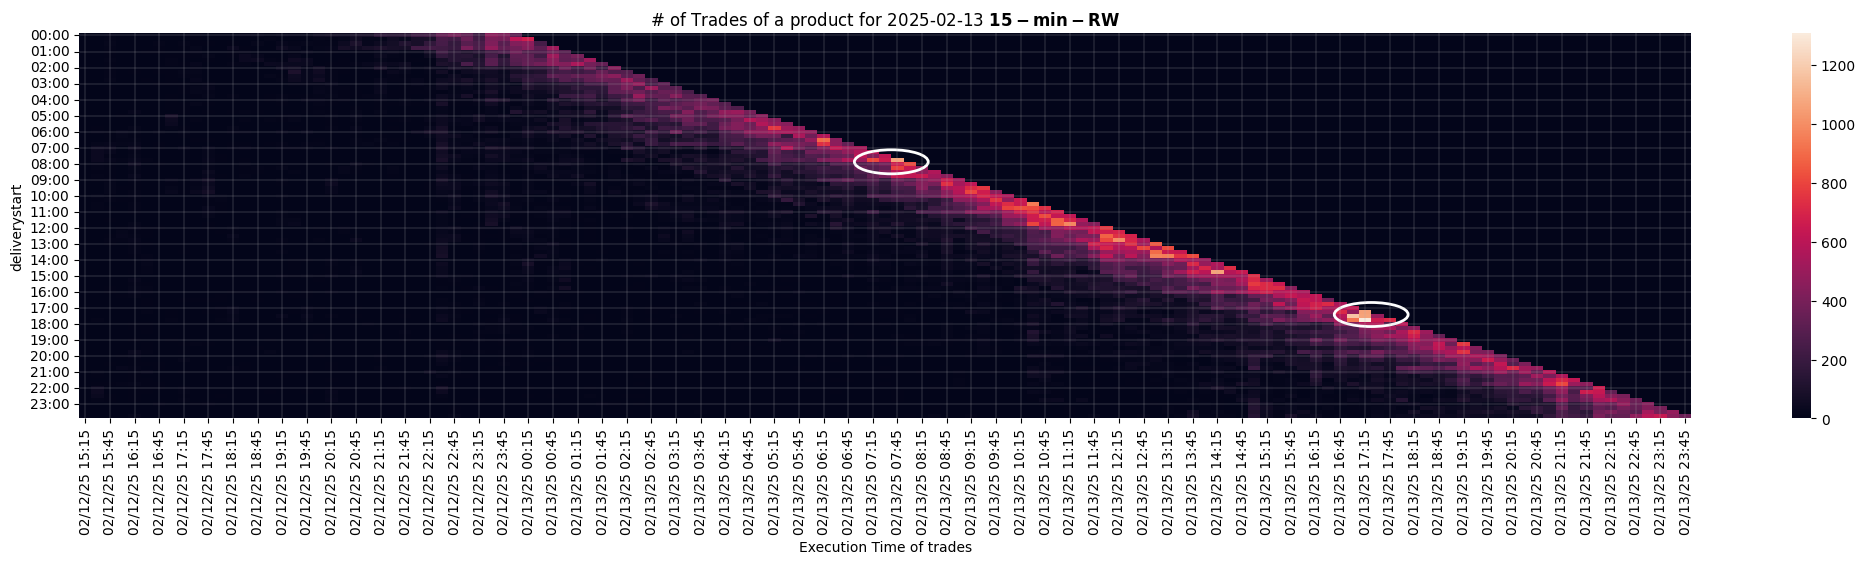

In [5]:
exec_time_range = slice(pd.Timestamp("02.12.2025",tz="Europe/Berlin"),
                        pd.Timestamp("02.14.2025",tz="Europe/Berlin"))
df_temp = df.loc[exec_time_range,:].copy()
start_delivery = df_temp.index[-1].normalize()
end_delivery = start_delivery.replace(hour=23,minute=45)

filter = (df_temp.deliverystart >= start_delivery) & (df_temp.deliverystart <= end_delivery)
df_temp["buckets"] = df_temp.index.ceil("15min")
df_temp = df_temp[filter]

counts = df_temp.groupby(["buckets","deliverystart"]).size().reset_index(name="n_trades")
heatmap = counts.pivot(columns="buckets",index="deliverystart",values="n_trades").fillna(0)
heatmap.index = heatmap.index.strftime("%H:%M")
heatmap.columns = heatmap.columns.strftime("%D %H:%M")

_,ax = plt.subplots(1,1,figsize=(26,5))
ax.set_title(f"# of Trades of a product for {start_delivery.date()} "+r"$\bf{15-min - RW}$")
ax.grid(True,linewidth=0.2)

sns.heatmap(heatmap,ax = ax)
ax.xaxis.set_tick_params(rotation=90)
ax.set_xlabel("Execution Time of trades")
patch = [plt.Circle(xy=(66,32),edgecolor="White",fill=False,radius=3,lw=2),
        plt.Circle(xy=(105,96*0.73),edgecolor="White",fill=False,radius=3,lw=2)]
ax.add_patch(patch[0])
ax.add_patch(patch[1])

The table below investigates one of the huge price spikes circled:
- The Product is 2025-02-13 08:00:00 - 2025-02-13 08:15:00
- The trade was executed at 3267.12 € with a volume of 0.225 MWh  
There was only **1 such trade**!   
In smaller windows this will **significantly increase the VWAP**, but you may not find buyers at such a price, because this price was a unique event rather than a trend !

#### What caused the bright circles at **8 am** ?

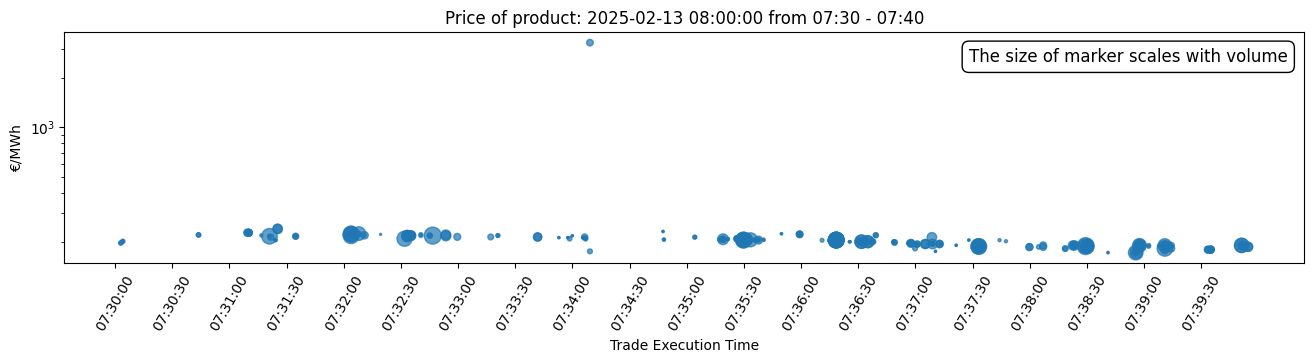

In [6]:
plot_product_price = df_temp[(df_temp.index > "2025-02-13 07:30:00") &\
        (df_temp.index < "2025-02-13 07:40:00") &\
        (df_temp.deliverystart == "2025-02-13 08:00:00+01:00")]\
                .sort_values("price",ascending=False)

plt.figure(figsize=(16, 3))
plt.scatter(x=plot_product_price.index,y=plot_product_price.price,
        s=plot_product_price["volume"] * 100,       # marker size (adjust multiplier as needed)
        c="tab:blue",                             # marker color
        alpha=0.7,
        marker="o",
)
plt.title("Price of product: 2025-02-13 08:00:00 from 07:30 - 07:40",)       
plt.ylabel("€/MWh")
plt.xlabel("Trade Execution Time")
x_ticks=pd.date_range(plot_product_price.index.min().replace(second=0),
                      plot_product_price.index.max(),
                      freq="30s")
plt.xticks(ticks = x_ticks,
           labels = x_ticks.strftime("%H:%M:%S"),
           rotation=60
           )                
plt.yscale(value="log")
plt.annotate(
    "The size of marker scales with volume",
    xy=(plot_product_price.price.idxmax(), plot_product_price.price.max()),   # Point to a real data point
    xytext=(plot_product_price.sort_index().index[-100], 2500),  # Place text above the plot
   
    fontsize=12,
    color="black",
    bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", lw=1)
)
plt.show()


In [7]:
exec_time_range = slice(pd.Timestamp("02.12.2025",tz="Europe/Berlin"),
                        pd.Timestamp("02.14.2025",tz="Europe/Berlin"))
df_temp_5 = df.loc[exec_time_range,:].copy()
df_temp_15 = df.loc[exec_time_range,:].copy()
start_delivery = df_temp.index[-1].normalize()
end_delivery = start_delivery.replace(hour=23,minute=45)

filter_5 = (df_temp_5.deliverystart >= start_delivery) & (df_temp_5.deliverystart <= end_delivery)
filter_15 = (df_temp_15.deliverystart >= start_delivery) & (df_temp_15.deliverystart <= end_delivery)
df_temp_5["buckets"] = df_temp_5.index.ceil("5min")
df_temp_15["buckets"] = df_temp_5.index.ceil("15min")
df_temp_5 = df_temp_5[filter_5]
df_temp_15 = df_temp_15[filter_15]
df_vwap_5 = df_temp_5.groupby(["buckets","deliverystart"]).apply(lambda x: sum((x.price * x.volume))/x.volume.sum())
df_vwap_15 = df_temp_15.groupby(["buckets","deliverystart"]).apply(lambda x: sum((x.price * x.volume))/x.volume.sum())

 Since both buckets close at 07:45, the products they can trade have delivery start 08:00!  
Look at the above chart. Notice the following challenges:
1. There is significant mismatch in product prices from 08:00 to 09:00 in between the two windows.
   * This could results in your ask/bid requests on the market not clearing in a realistic scenario.
   * However, for products beyond that, the VWAP seems to be quite similar between both windows
2. A calibration is necessary for products close to delivery. Larger windows may require attributing higher weights for products close to delivery
3. In terms of volatility, there doesnt seem to be a big difference between the two curves but this may require a more thorough investigation
4. The curves is incomplete for shorter windows 
   * Could this have detrimental effects on overall trading?


***

### Bucket size and VWAP - Curve

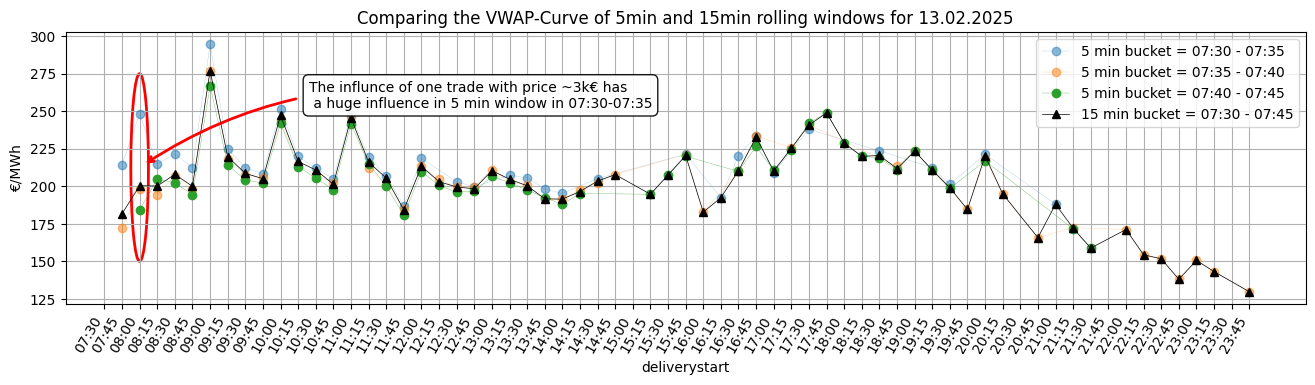

In [8]:
### 5 min RW VWAP
df_vwap_5.loc["2025-02-13 07:35:0"].plot(x="deliverystart",
                                         figsize=(16,4),
                                         ylabel="€/MWh",
                                         label=f"5 min bucket = 07:30 - 07:35",
                                         lw=0.2,
                                         marker="o",
                                         alpha=0.5)


df_vwap_5.loc["2025-02-13 07:40:0"].plot(x="deliverystart",
                                         figsize=(16,4),
                                         ylabel="€/MWh",
                                         label=f"5 min bucket = 07:35 - 07:40",
                                         lw=0.2,
                                         marker="o",
                                         alpha=0.5)


ax=df_vwap_5.loc["2025-02-13 07:45:0"].plot(x="deliverystart",
                                         figsize=(16,4),
                                         ylabel="€/MWh",
                                         label=f"5 min bucket = 07:40 - 07:45",
                                         lw=0.2,
                                         marker="o",
                                         alpha=1)
                                         
x_axis=df_vwap_5.loc["2025-02-13 07:45:0"].index

# 15min RW VWAP
df_vwap_15[slice("2025-02-13 07:35:0","2025-02-13 07:45:0")].droplevel(0)\
         .plot(x="deliverystart",
          label="15 min bucket = 07:30 - 07:45",
          marker="^",
          lw=0.5,
          color="black")

plt.legend(loc="best")
plt.grid(True,which="both")
x_ticks = pd.date_range(x_axis[0].replace(hour=7,minute=30,second=0),
                         x_axis[-1].replace(hour=23,minute=45,second=0),
                         freq="15min")
x_labels = x_ticks.strftime('%H:%M')
plt.xticks(x_ticks,x_labels,rotation=60)
plt.title("Comparing the VWAP-Curve of 5min and 15min rolling windows for 13.02.2025")

# Ellipse parameters
x_center = pd.Timestamp("2025-02-13 08:00:00+01:00")
ymin = 150
ymax = 275
y_center = (ymax + ymin) / 2
height = ymax - ymin

# Set width to 1 hour (in matplotlib date units)
width = pd.Timedelta(hours=1) / pd.Timedelta(days=1)  # width in "days" for matplotlib

# Ellipse parameters
x_center = pd.Timestamp("2025-02-13 08:00:00+01:00")
ymin = 150
ymax = 275
y_center = (ymax + ymin) / 2
height = ymax - ymin

# Set width to 1 hour (in matplotlib date units)
width = pd.Timedelta(hours=.25) / pd.Timedelta(days=1)  # width in "days" for matplotlib

# Convert timestamp to matplotlib float
x_center_float = mdates.date2num(x_center)

# Draw the ellipse on the axes returned by the last plot (ax)
ell = Ellipse(
    xy=(x_center_float, y_center),
    width=width,
    height=height,
    edgecolor='red',
    facecolor='none',
    lw=2
)
ax.add_patch(ell)
ax.annotate(text="The influnce of one trade with price ~3k€ has\n a huge influence in 5 min window in 07:30-07:35",
            xy=(x_center_float, y_center),
            xytext = (x_center_float + 0.1, y_center + 40),
            arrowprops={
                "arrowstyle": "->",      # Simple arrow
                "color": "red",        # Arrow color matches text
                "lw": 2,                 # Line width
                "shrinkA": 5,            # Shorten arrow at the start
                "shrinkB": 5,            # Shorten arrow at the end (optional)
                "connectionstyle": "arc3,rad=0.2"  # Curved arrow (optional, adjust as needed)
            },
             bbox=dict(
            boxstyle="round,pad=0.4",      # Rounded box with padding
            fc="white",                    # Facecolor (background) is white
            ec="black",                    # Edgecolor is black
            lw=1,                          # Line width
            alpha=0.9                      # Slight transparency
            ),
            )
plt.show()

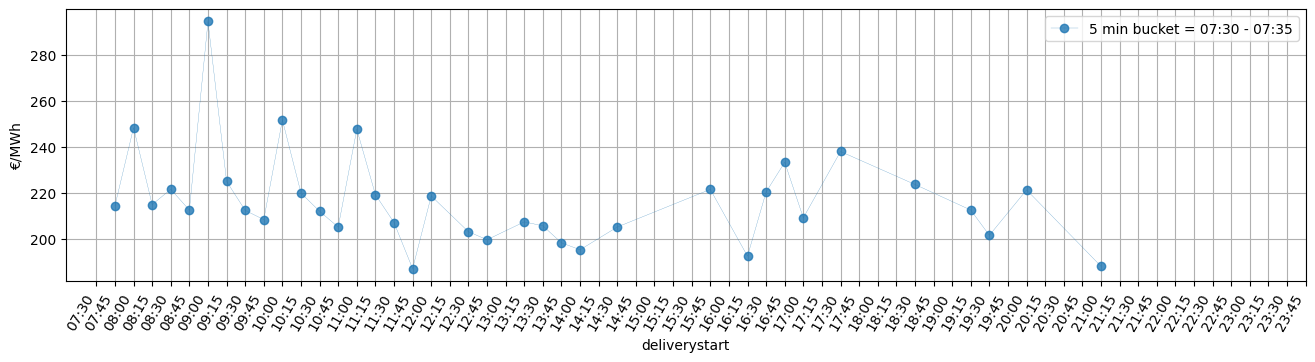

In [9]:
df_vwap_5.loc["2025-02-13 07:35:0"].plot(x="deliverystart",
                                         figsize=(16,4),
                                         ylabel="€/MWh",
                                         label=f"5 min bucket = 07:30 - 07:35",
                                         lw=0.2,
                                         marker="o",
                                         alpha=0.8).grid(True)


plt.legend(loc="best")
plt.grid(True,which="both")
x_ticks = pd.date_range(x_axis[0].replace(hour=7,minute=30,second=0),
                         x_axis[-1].replace(hour=23,minute=45,second=0),
                         freq="15min")
x_labels = x_ticks.strftime('%H:%M')
plt.xticks(x_ticks,x_labels,rotation=60)
plt.show()



***

### How does the optimizer work?

For each delivery interval $i \in \mathcal{T}$ (with $i$ denoting the $\emph{start}$ of the delivery period), 
the following constraint is added:
$
\begin{equation}
    z_i - w_i 
    \;=\; \text{current\_buy}_i
          + \text{prev\_net\_buy}_i
          - \text{current\_sell}_i
          - \text{prev\_net\_sell}_i .
\end{equation}
$

For each delivery interval $i \in \mathcal{T}$, the following constraints enforce 
that the battery cannot charge and discharge simultaneously:

$
\begin{align}
    \text{net\_buy}_i &\;\leq\; M \cdot \text{charge\_sign}_i, 
        && \forall i \in \mathcal{T},  \\[6pt]
    \text{net\_sell}_i &\;\leq\; M \cdot (1 - \text{charge\_sign}_i), 
        && \forall i \in \mathcal{T}. 
\end{align}
$
##### Interpretation:
Equation above enforces that the **net power scheduled for delivery in interval $i$**
(as represented by $z_i - w_i$) must equal the sum of:

* newly optimized buy and sell decisions in the current step 
          ($\text{current\_buy}_i, \text{current\_sell}_i$), and
* previously committed net trades for the same delivery period
          ($\text{prev\_net\_buy}_i, \text{prev\_net\_sell}_i$).


In other words, $z_i - w_i$ captures the $\emph{effective net injection}$ (positive = charging from the grid,
negative = discharging to the grid) that the battery must deliver at the beginning of delivery slot $i$,
after accounting for both new and prior market commitments.

##### Variables:

  * $z_i \geq 0$: auxiliary variable equal to the active net charging flow if the battery is in charging mode at $i$, and zero otherwise.
  * $w_i \geq 0$: auxiliary variable equal to the active net discharging flow if the battery is in discharging mode at $i$, and zero otherwise.
  * $\text{current\_buy}_i \geq 0$: power (kW) bought in the market for delivery in interval $i$.
  * $\text{current\_sell}_i \geq 0$: power (kW) sold in the market for delivery in interval $i$.
  * $\text{charge\_sign}_i \in \{0,1\}$ is a binary mode indicator.
  * $\text{net\_buy}_i$ and $\text{net\_sell}_i \in \{0,c\_rate * Capacity\}$ ensure that you stay within power limits of BESS

##### Parameters:

  * $\text{prev\_net\_buy}_i \geq 0$: volume of buy commitments previously scheduled for delivery in interval $i$.
  * $\text{prev\_net\_sell}_i \geq 0$: volume of sell commitments previously scheduled for delivery in interval $i$.



***

### So far we have only looked at market data. The next step is to consider how the plots from BESS trading activities should look!

### Task 1 : Visualize trades by BESS and Do it with an interactive chart in streamlit!

Desired goals of streamlit dashboard:
- [x] Show individual days revenue
- [x] Show cummulative revenue of chosen period
- [x] On the side show the Bess parameters
- [x] Enable adjustment of simulation parameters
- [x] Enable adjustment of BESS parameters
- [x] Enable Running of Simulation!

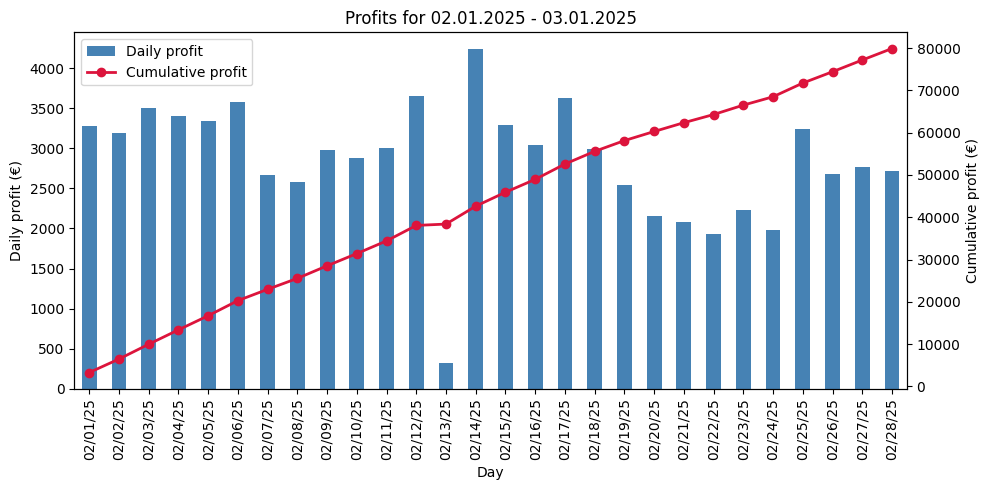

In [10]:
filter = slice("02.01.2025","03.01.2025")
initial_results = pd.read_csv("../../Dashboard/demo_output/quarterhourly/bs10cr1rto0.85mc30.416666666666668mt5/profit.csv",
                              index_col="day",
                              parse_dates=True
                              )
initial_results.index = initial_results.index.strftime("%D")
initial_results = initial_results[filter]
# ── build the figure ───────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))

# 1️⃣ daily profit – bar chart on the left y-axis
initial_results["profit"].plot(
    kind="bar",
    color="steelblue",
    ax=ax1,
    label="Daily profit",
)
ax1.set_ylabel("Daily profit (€)")

# 2️⃣ cumulative profit – line on the right y-axis
ax2 = ax1.twinx()                                 # second y-axis
initial_results["profit"].cumsum().plot(
    ax=ax2,
    color="crimson",
    marker="o",
    linewidth=2,
    label="Cumulative profit",
)
ax2.set_ylabel("Cumulative profit (€)")
# cosmetics
ax1.set_xlabel("Day")
ax1.tick_params(axis="x")
# combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
ax1.set_title(f"Profits for {filter.start} - {filter.stop}")
plt.tight_layout()

**The above result does not match data from ISEA Battery Index**

In [25]:
path="../../Dashboard/demo_output/quarterhourly/bs10cr1rto0.85mc30.416666666666668mt5/trades/trades_2025-02-01.csv"
path=os.path.normpath(path)
trades_01_02_2025=pd.read_csv(path)
trades_01_02_2025

,execution_time,side,quantity,price,product,profit
0,2025-01-31 16:00:00+01:00,buy,0.176471,111.86,2025-02-01 04:00:00+01:00,-4.935000
1,2025-01-31 16:00:00+01:00,buy,1.000000,108.91,2025-02-01 05:00:00+01:00,-27.227500
2,2025-01-31 16:00:00+01:00,sell,1.000000,143.26,2025-02-01 10:00:00+01:00,35.815000
3,2025-01-31 16:00:00+01:00,buy,1.000000,100.08,2025-02-01 11:45:00+01:00,-25.020000
4,2025-01-31 16:00:00+01:00,buy,1.000000,98.37,2025-02-01 13:00:00+01:00,-24.592500
...,...,...,...,...,...,...
463,2025-02-01 18:50:00+01:00,buy,0.012182,118.72,2025-02-01 23:30:00+01:00,-0.361568
464,2025-02-01 18:50:00+01:00,buy,0.150000,108.99,2025-02-01 23:45:00+01:00,-4.087125
465,2025-02-01 19:00:00+01:00,sell,0.012182,116.43,2025-02-01 23:30:00+01:00,0.354594
466,2025-02-01 19:00:00+01:00,sell,0.137818,107.75,2025-02-01 23:45:00+01:00,3.712466


In [58]:
df.loc[slice("2025-02-28 16:00","2025-02-28 16:10"),["deliverystart","price","volume"]]

,deliverystart,price,volume
executiontime,,,
2025-02-28 16:00:00.533000+01:00,2025-02-28 19:00:00+01:00,160.11,0.025
2025-02-28 16:00:00.533000+01:00,2025-02-28 19:00:00+01:00,160.11,0.025
2025-02-28 16:00:00.535000+01:00,2025-02-28 19:00:00+01:00,161.64,0.250
2025-02-28 16:00:00.535000+01:00,2025-02-28 19:00:00+01:00,161.64,0.250
2025-02-28 16:00:01.085000+01:00,2025-02-28 17:30:00+01:00,154.26,0.075
...,...,...,...
2025-02-28 16:10:55.116000+01:00,2025-02-28 17:45:00+01:00,160.00,0.225
2025-02-28 16:10:55.116000+01:00,2025-02-28 17:45:00+01:00,160.00,0.050
2025-02-28 16:10:59.939000+01:00,2025-02-28 16:45:00+01:00,146.30,0.025


In [70]:
df.loc[slice("2025-02-28 15:00","2025-02-28 15:00"),["deliverystart","price","volume"]]\
    .groupby("deliverystart")\
        .apply(lambda x: x.price.mul(x.volume) )

deliverystart              executiontime                   
2025-02-28 15:15:00+01:00  2025-02-28 15:00:01.652000+01:00     2.50150
                           2025-02-28 15:00:01.652000+01:00     2.50150
                           2025-02-28 15:00:01.652000+01:00    12.50750
                           2025-02-28 15:00:02.504000+01:00    15.65625
                           2025-02-28 15:00:02.504000+01:00    15.65625
                                                                 ...   
2025-02-28 22:00:00+01:00  2025-02-28 15:00:50.632000+01:00     3.37450
                           2025-02-28 15:00:50.632000+01:00    70.86450
                           2025-02-28 15:00:50.632000+01:00     3.32600
                           2025-02-28 15:00:50.632000+01:00    66.66500
                           2025-02-28 15:00:50.632000+01:00     9.97725
Length: 485, dtype: float64

In [76]:
filter = (df.deliverystart > pd.Timestamp("2025-02-28 23:45",tz="Europe/berlin")) &\
        (df.side=="BUY")
df[filter]#.loc[slice("2025-02-28 15:00","2025-02-28 15:10"),["deliverystart","price","volume"]]

,side,product,deliverystart,deliveryend,tradephase,price,volume
executiontime,,,,,,,
2025-03-01 15:01:10.709000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-02 20:30:00+01:00,2025-03-02 20:45:00+01:00,CONT,94.49,0.200
2025-03-01 15:01:14.086000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-02 17:30:00+01:00,2025-03-02 17:45:00+01:00,CONT,114.26,0.025
2025-03-01 15:01:14.313000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-02 19:15:00+01:00,2025-03-02 19:30:00+01:00,CONT,120.49,0.025
2025-03-01 15:01:14.515000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-02 19:45:00+01:00,2025-03-02 20:00:00+01:00,CONT,108.95,0.075
2025-03-01 15:02:53.242000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-02 19:30:00+01:00,2025-03-02 19:45:00+01:00,CONT,121.80,0.150
...,...,...,...,...,...,...,...
2025-03-25 23:39:16.028000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-25 23:45:00+01:00,2025-03-26 00:00:00+01:00,CONT,72.69,0.425
2025-03-25 23:39:19.208000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-25 23:45:00+01:00,2025-03-26 00:00:00+01:00,CONT,65.00,0.900
2025-03-25 23:39:21.011000+01:00,BUY,XBID_Quarter_Hour_Power,2025-03-25 23:45:00+01:00,2025-03-26 00:00:00+01:00,CONT,65.00,0.100


### To Do:
##### Conduct the following tests:
- [x] 1, 5, 10, 15 min rolling windows and difference in revenue 
- [ ] Enable a forecast based approach and compare the performance

***

# Comparing outcomes of different window sizes

In [10]:
df_bs_5 = pd.read_csv("../../Dashboard/demo_output/quarterhourly/bs5cr1rto0.85mc30.416666666666668mt5/profit.csv")
df_bs_10 = pd.read_csv("../../Dashboard/demo_output/quarterhourly/bs10cr1rto0.85mc30.416666666666668mt5/profit.csv")
df_bs_15 =pd.read_csv("../../Dashboard/demo_output/quarterhourly/bs10cr1rto0.85mc30.416666666666668mt5/profit.csv")

In [11]:
import plotly.graph_objects as go
import plotly.express as ex
from plotly.subplots import make_subplots

In [12]:
x = df_bs_10["day"]
fig = make_subplots()

# bars on left axis
fig.add_bar(name="BS15", x=x, y=df_bs_15["profit"], offsetgroup=1, secondary_y=False,marker_color="red")

fig.add_bar(name="BS10", x=x, y=df_bs_10["profit"], offsetgroup=0, secondary_y=False,marker_color="blue")

fig.add_bar(name="BS5",  x=x, y=df_bs_5["profit"],  offsetgroup=2, secondary_y=False,marker_color="green")


fig.update_layout(barmode="group", xaxis_title="Day",
                  yaxis_title="Daily (€)",
                  title="Daily profits in February with different Bucket Sizes (BS)")

In [13]:
fig = make_subplots(1,2,column_widths=[0.8,0.2],subplot_titles=["Cummulative Revenue for Different BS","% revenue relative to base case with 15 min BS"])
# cumulative on right axis
fig.add_scatter(name="BS15 cummulative", x=x, y=df_bs_15["profit"].cumsum(),
                mode="lines+markers",line_color="red")

fig.add_scatter(name="BS10 cummulative", x=x, y=df_bs_10["profit"].cumsum(),
                mode="lines+markers", line_color="blue")

fig.add_scatter(name="BS5 cummulative",  x=x, y=df_bs_5["profit"].cumsum(),
                mode="lines+markers", line_color="green")

fig.update_layout( xaxis_title="Day",
                  yaxis_title="Daily Cummulative (€)",
                  )

df_sum = pd.DataFrame(data=np.array([df_bs_15.profit.sum(),df_bs_10.profit.sum(),df_bs_5.profit.sum()]),columns=["revenue"])

df_sum.index = ["BS15","BS10","BS5"] 
df_sum = df_sum.divide(df_sum.loc["BS15",:],axis=1)
df_sum.loc[:,"color"] = ["red","Blue","Green"]
fig.add_bar(
    row=1,col=2,
    x = df_sum.index,
    y = df_sum["revenue"],
    marker_color = df_sum["color"]
    )


***